In [1]:
using CovidSim_ilm

[ Info: For saving to png with the Plotly backend PlotlyBase has to be installed.


In [2]:
# Run this when actively modifying the code in the package
using Pkg
Pkg.develop(path="/Users/lewis/Dropbox/Covid Modeling/Covid-ILM")

   Resolving package versions...


  No Changes to `~/.julia/environments/v1.7/Project.toml`
  No Changes to `~/.julia/environments/v1.7/Manifest.toml`


In [3]:
cs = CovidSim_ilm

CovidSim_ilm

In [4]:
using StatsBase
using TypedTables
using BenchmarkTools
using Distributions
using YAML
using PrettyPrint
using LinearAlgebra
using Dates
using Plots
using TableView
using SplitApplyCombine
using Tables
using PrettyTables

In [6]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/src"))

# Test setup and population matrix

In [7]:
ndays = 180
locale = 38015
model180 = buildsim(ndays, locale;  
    day1 = Date("2020-01-01", "yyyy-mm-dd"),
    dovax = true,
    paramdir = "../sample_parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    scheddir = "vaccine_100k",
    variantfilename = "variants.yml",
);

### R0 Simulation

In [8]:
r0 = cs.r0_sim(200_000, model180.progressionset, model180.trvec, model180.infectset, 
                model180.vaxset, model180.social, false, :base, 1.0, 3)

1.9743589743589745

In [9]:
r0 = cs.r0_sim(200_000, model180.progressionset, model180.trvec, model180.infectset, 
                model180.vaxset, model180.social, false, :omicron_ba1, 1.0, 3)

2.4615384615384617

### Seed the model with the :base variant spreaders

In [10]:

seed20_39_day1 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);
seed40_59_day1 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);           

### Run the simulation

In [11]:
popdat, series = runsim(model180;
            dovax=true, vaxscheds=:all,
            runcases=[seed20_39_day1, seed40_59_day1]  
            );
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]



Execution Times
Indexing    0.006
Vaccination 0.002
Spread      0.668
Progression  0.361
History     0.871
Total       2.577


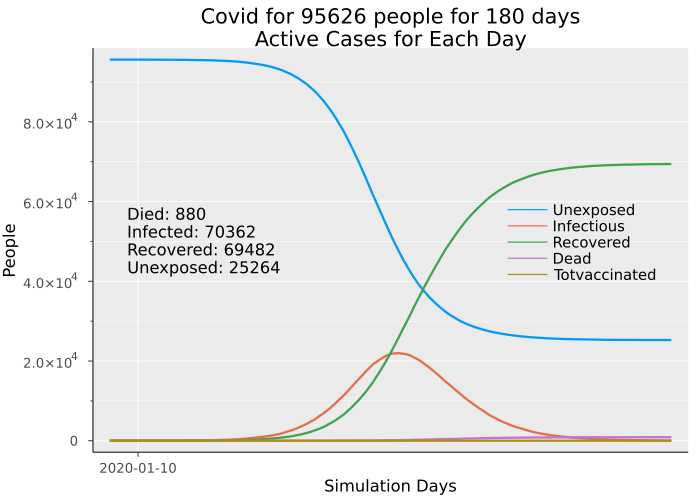

In [12]:
cumplot(series, locale, [:unexposed, :infectious, :recovered, :dead, :totvaccinated])

In [13]:
popdat, series = runsim(model180;
            dovax=true, vaxscheds=:all, showr0=true,
            runcases=[seed20_39_day1, seed40_59_day1]  
            );
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]



Execution Times
Indexing    0.006
Vaccination 0.001
Spread      0.847
Progression  0.209
History     0.314
Total       5.889


Day: 10 Locale: 38015 Current r(t): 1.6804123711340206 
Day: 20 Locale: 38015 Current r(t): 1.6451612903225807 
Day: 30 Locale: 38015 Current r(t): 1.5876288659793814 
Day: 40 Locale: 38015 Current r(t): 1.2378378378378379 
Day: 50 Locale: 38015 Current r(t): 1.2321041214750543 
Day: 60 Locale: 38015 Current r(t): 1.1366053169734152 
Day: 70 Locale: 38015 Current r(t): 1.032711026009255 
Day: 80 Locale: 38015 Current r(t): 0.9098305590803911 
Day: 90 Locale: 38015 Current r(t): 0.7264192245950285 
Day: 100 Locale: 38015 Current r(t): 0.660576415863425 
Day: 110 Locale: 38015 Current r(t): 0.6678936605316973 
Day: 120 Locale: 38015 Current r(t): 0.6972594752186589 
Day: 130 Locale: 38015 Current r(t): 0.712491738268341 
Day: 140 Locale: 38015 Current r(t): 0.761926817971283 
Day: 150 Locale: 38015 Current r(t): 0.8023952095808383 
Day: 160 Locale: 38015 Current r(t): 0.8278008298755186 
Day: 170 Locale: 38015 Current r(t): 0.908745247148289 
Day: 180 Locale: 38015 Current r(t): 1.049689

In [37]:
cs.r0_table(10, 1.1, 0.18; popsize=200_000, progressionset=model180.progressionset, 
        trvec=model180.trvec, infectset=model180.infectset, vaxset=model180.vaxset, 
        socialparams=model180.social, dovax=false, variant=:base, density_factor=1.0, scale=3)


11×11 Matrix{Float64}:
 0.0   1.1   1.2   1.3   1.4   1.5   1.6   1.7   1.8   1.9   2.0
 0.18  1.88  2.1   1.74  1.82  1.63  1.63  1.76  1.99  1.86  1.65
 0.23  1.97  2.08  2.01  2.18  1.68  2.13  1.92  1.81  1.81  2.32
 0.28  1.76  2.06  1.95  1.85  1.72  1.9   1.79  1.65  1.63  1.83
 0.33  1.9   2.0   2.09  1.9   1.76  1.59  1.79  1.78  2.0   2.05
 0.38  1.83  1.92  1.67  2.14  1.83  1.88  1.91  2.22  1.94  1.81
 0.43  1.94  1.88  2.09  2.04  1.69  2.05  1.94  1.74  2.03  2.04
 0.48  1.94  1.4   2.0   1.86  1.82  1.99  1.97  1.92  1.79  1.92
 0.53  1.64  2.12  1.86  2.03  1.87  1.99  1.67  1.96  1.99  1.87
 0.58  1.91  1.67  1.97  2.06  1.9   1.86  1.99  1.82  1.97  1.67
 0.63  1.83  1.79  1.82  1.83  1.69  1.72  1.55  1.82  1.65  1.9

11×11 Matrix{Float64}:
 0.0   1.1   1.2   1.3   1.4   1.5   1.6   1.7   1.8   1.9   2.0
 0.18  1.88  2.1   1.74  1.82  1.63  1.63  1.76  1.99  1.86  1.65
 0.23  1.97  2.08  2.01  2.18  1.68  2.13  1.92  1.81  1.81  2.32
 0.28  1.76  2.06  1.95  1.85  1.72  1.9   1.79  1.65  1.63  1.83
 0.33  1.9   2.0   2.09  1.9   1.76  1.59  1.79  1.78  2.0   2.05
 0.38  1.83  1.92  1.67  2.14  1.83  1.88  1.91  2.22  1.94  1.81
 0.43  1.94  1.88  2.09  2.04  1.69  2.05  1.94  1.74  2.03  2.04
 0.48  1.94  1.4   2.0   1.86  1.82  1.99  1.97  1.92  1.79  1.92
 0.53  1.64  2.12  1.86  2.03  1.87  1.99  1.67  1.96  1.99  1.87
 0.58  1.91  1.67  1.97  2.06  1.9   1.86  1.99  1.82  1.97  1.67
 0.63  1.83  1.79  1.82  1.83  1.69  1.72  1.55  1.82  1.65  1.9

In [15]:
tf_orig = model180.social.touchfactors

6×5 Matrix{Float64}:
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.62  0.58  0.41  0.28
 0.28  0.35  0.3   0.18  0.18
 0.18  0.18  0.18  0.18  0.18

In [18]:
cg_orig = model180.social.contactfactors

4×5 Matrix{Float64}:
 1.1  2.1  2.1  1.7  1.0
 1.1  2.0  2.0  1.6  0.9
 0.7  1.0  1.0  0.7  0.6
 0.5  0.6  0.6  0.5  0.5

In [19]:
shifter(tf_orig, 0.1, 0.7)

6×5 Matrix{Float64}:
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.686667  0.633333  0.406667  0.233333
 0.233333  0.326667  0.26      0.1       0.1
 0.1       0.1       0.1       0.1       0.1

In [20]:
model180.social.touchfactors

6×5 Matrix{Float64}:
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.63  0.61  0.41  0.35
 0.55  0.62  0.58  0.41  0.28
 0.28  0.35  0.3   0.18  0.18
 0.18  0.18  0.18  0.18  0.18

In [23]:
model180.social.touchfactors .= shifter(model180.social.touchfactors, 0.1, 0.7)

6×5 Matrix{Float64}:
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.686667  0.633333  0.406667  0.233333
 0.233333  0.326667  0.26      0.1       0.1
 0.1       0.1       0.1       0.1       0.1

In [24]:
model180.social.touchfactors

6×5 Matrix{Float64}:
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.7       0.673333  0.406667  0.326667
 0.593333  0.686667  0.633333  0.406667  0.233333
 0.233333  0.326667  0.26      0.1       0.1
 0.1       0.1       0.1       0.1       0.1

In [26]:
model180.social.touchfactors .= shifter(model180.social.touchfactors, 0.18,0.63)

6×5 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN

In [ ]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])  